# 15 — Dynamic Programming: Value Iteration
*A from-scratch walkthrough of the Bellman optimality backup to compute $v^*$ and an optimal policy.*

**What you'll learn**
- How value iteration applies the Bellman optimality operator
- Convergence + stopping criteria ($\theta$) and the role of $\gamma$
- Extracting an optimal greedy policy from $v$
- Visualizing $v$, $\Delta$ (max update), and the learned policy

> We’ll use a small GridWorld so everything is transparent and implementable from scratch.

## 1. Value Iteration — Core Idea

Value Iteration computes the optimal value function by repeatedly applying the Bellman optimality backup:

$$
v_{k+1}(s) \;=\; \max_{a} \sum_{s'} P(s' \mid s,a)\Big( r(s,a,s') + \gamma\, v_k(s') \Big)
$$

At each iteration:
1. We assume the agent will act optimally from the next state onward.
2. For every state, we evaluate *all possible actions* and keep the one with the highest expected return.
3. Policy improvement is implicit, the greedy policy w.r.t. $v_k$ improves automatically.

Unlike policy evaluation, which evaluates a fixed policy, value iteration merges evaluation and improvement into a single loop.


### Why Value Iteration Converges

The Bellman optimality operator is a $\gamma$-contraction (for $\gamma \in [0,1)$):
- Each update shrinks the distance to the optimal value function by at least a factor of $\gamma$.
- This guarantees convergence to a unique fixed point $v^*$, independent of initialization.

Intuitively, future rewards are discounted, so repeated backups eventually stabilize.


### RL Connection

- Value iteration is the idealized planning algorithm for known MDPs.
- Q-learning, SARSA, and TD control approximate this same backup using samples instead of full transition models.
- In deep RL, the tabular value $v(s)$ is replaced by a neural network, but the training target still mirrors this Bellman optimality equation.

> Value iteration is the conceptual bridge between classical dynamic programming and modern reinforcement learning.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

# Helper: pretty arrows for policy visualization
ARROWS = {0:"↑", 1:"→", 2:"↓", 3:"←"}  # actions: 0=Up, 1=Right, 2=Down, 3=Left

## 2. A Simple GridWorld MDP

We use a 4 x 4 grid with:
- Two terminal states: top-left and bottom-right
- Deterministic transitions (attempted moves that hit a wall keep you in place)
- Per-step reward $r=-1$ until termination
- Discount $\gamma$

This is a “shortest path under step penalty” setting where the optimal policy moves toward a terminal in as few steps as possible.

In [2]:
H, W = 4, 4
nS = H * W  # number of states
nA = 4      # actions: Up, Right, Down, Left

# Action mapping for readability
ARROWS = {0: "↑", 1: "→", 2: "↓", 3: "←"}

# Terminal states: top-left (0,0) and bottom-right (3,3)
terminals = {0, nS - 1}

def to_rc(s):
    """State index -> (row, col)"""
    return divmod(s, W)

def to_s(r, c):
    """(row, col) -> state index"""
    return r * W + c

def step(s, a):
    """
    Deterministic transition function.
    Returns: next_state, reward, done
    """
    # Terminal states are absorbing
    if s in terminals:
        return s, 0.0, True

    r, c = to_rc(s)

    # Proposed move
    if a == 0:    # Up
        r2, c2 = r - 1, c
    elif a == 1:  # Right
        r2, c2 = r, c + 1
    elif a == 2:  # Down
        r2, c2 = r + 1, c
    else:         # Left
        r2, c2 = r, c - 1

    # Wall check: stay in place if outside grid
    if r2 < 0 or r2 >= H or c2 < 0 or c2 >= W:
        s2 = s
    else:
        s2 = to_s(r2, c2)

    done = (s2 in terminals)
    reward = 0.0 if done else -1.0

    return s2, reward, done

# Sanity check: transitions from state 1
print("Transitions from state 1:")
for a in range(nA):
    print(f"  action {ARROWS[a]} ->", step(1, a))

Transitions from state 1:
  action ↑ -> (1, -1.0, False)
  action → -> (2, -1.0, False)
  action ↓ -> (5, -1.0, False)
  action ← -> (0, 0.0, True)


## 3. Implementing Value Iteration

Value iteration alternates between estimating how good each state is and improving decisions using the Bellman optimality principle.

### Update rule (Bellman optimality backup)

At each iteration, we update every state by assuming we act optimally from the next step onward:

$$
v_{k+1}(s)
\;=\;
\max_a \sum_{s'} P(s' \mid s,a)
\big( r(s,a,s') + \gamma\, v_k(s') \big)
$$

This differs from policy evaluation:
- **Policy evaluation:** expectation under a *fixed* policy  
- **Value iteration:** maximization over actions at *every update*

So improvement and evaluation happen simultaneously.


### Stopping criterion

We repeat updates until the values stop changing significantly:

$$
\Delta_k = \max_s \big| v_{k+1}(s) - v_k(s) \big|
$$

When $\Delta_k < \theta$, we declare convergence.

Why this works:
- The Bellman optimality operator is a $\gamma$-contraction
- Repeated application converges to a unique fixed point $v^*$


### Extracting the optimal policy

Once the optimal value function $v^*$ is found, the optimal policy is obtained greedily:

$$
\pi^*(s)
\;\in\;
\arg\max_a \sum_{s'} P(s' \mid s,a)
\big( r(s,a,s') + \gamma\, v^*(s') \big)
$$

This step simply asks:
> *“Given the optimal values, which action is best in each state?”*


### Intuition

- Value iteration pushes information backward from terminal states
- Each update improves estimates of how far a state is from termination
- In GridWorld, values become *negative distances* to the nearest terminal
- The resulting policy always moves along the shortest path

Understanding value iteration means understanding the core logic behind *almost all* RL control algorithms.

In [3]:
def value_iteration(gamma=0.95, theta=1e-10, max_iters=10_000):
    """
    Synchronous Value Iteration:
      v_{k+1}(s) = max_a [ r(s,a,s') + gamma * v_k(s') ]
    """
    v = np.zeros(nS, dtype=float)
    deltas = []

    for it in range(max_iters):
        v_new = v.copy()
        delta = 0.0

        for s in range(nS):
            if s in terminals:
                v_new[s] = 0.0
                continue

            # Bellman optimality backup (deterministic transitions here)
            q_sa = np.empty(nA, dtype=float)
            for a in range(nA):
                s2, r, done = step(s, a)
                q_sa[a] = r + gamma * v[s2]  # use OLD v (synchronous)

            v_new[s] = np.max(q_sa)
            delta = max(delta, abs(v_new[s] - v[s]))

        v = v_new
        deltas.append(delta)

        if delta < theta:
            break

    return v, np.array(deltas)


def greedy_policy_from_v(v, gamma=0.95, tie_break="first"):
    """
    Extract greedy policy:
      pi(s) = argmax_a [ r + gamma * v(s') ]
    tie_break:
      - "first": np.argmax (first max)
      - "random": random among ties (useful in symmetric grids)
    """
    pi = np.full(nS, -1, dtype=int)
    rng = np.random.default_rng(0)

    for s in range(nS):
        if s in terminals:
            pi[s] = -1
            continue

        q_sa = np.empty(nA, dtype=float)
        for a in range(nA):
            s2, r, done = step(s, a)
            q_sa[a] = r + gamma * v[s2]

        if tie_break == "random":
            best = np.flatnonzero(q_sa == q_sa.max())
            pi[s] = int(rng.choice(best))
        else:
            pi[s] = int(np.argmax(q_sa))

    return pi


# Run
gamma = 0.95
v_star, deltas = value_iteration(gamma=gamma, theta=1e-10, max_iters=10_000)
pi_star = greedy_policy_from_v(v_star, gamma=gamma, tie_break="first")

print("Iterations:", len(deltas))
print("Final max Δ:", deltas[-1] if len(deltas) else None)
print("v* reshape:\n", np.round(v_star.reshape(H, W), 3))

Iterations: 3
Final max Δ: 0.0
v* reshape:
 [[ 0.    0.   -1.   -1.95]
 [ 0.   -1.   -1.95 -1.  ]
 [-1.   -1.95 -1.    0.  ]
 [-1.95 -1.    0.    0.  ]]


## 4. Visualizing the Optimal Value Function and Policy

To better understand the result of value iteration, we visualize three key artifacts:

- **Optimal value function $v^*$**  
  Displayed as a heatmap over the grid, where brighter cells indicate higher expected return. This shows how “good” each state is under optimal behavior.

- **Greedy policy $\pi^*$ induced by $v^*$**  
  Each arrow indicates the action that maximizes the Bellman optimality backup at that state. Terminal states are marked with ■ since no action is taken there.

- **Convergence diagnostics**  
  We plot the maximum Bellman update change

  $$
  \Delta_k = \max_s |v_{k+1}(s) - v_k(s)|
  $$
  
  to confirm contraction and convergence to the fixed point.

Together, these plots provide:
- geometric intuition for shortest-path behavior,
- a sanity check that the policy points toward terminal states,
- and empirical evidence that value iteration converges as theory predicts.

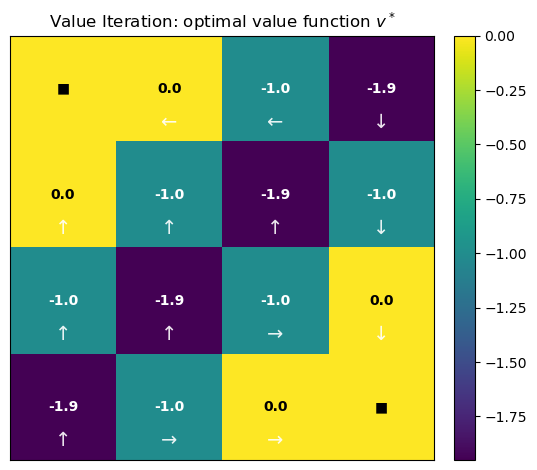

Optimal policy (arrows):
■ ← ← ↓
↑ ↑ ↑ ↓
↑ ↑ → ↓
↑ → → ■


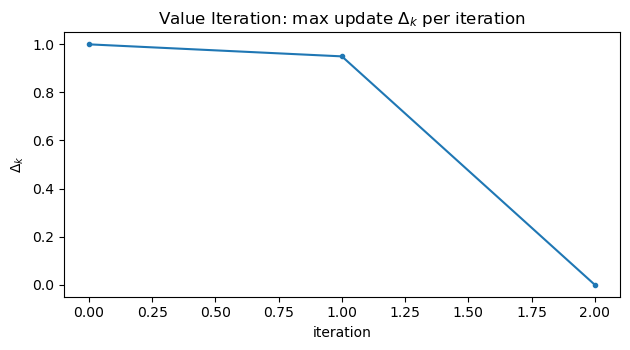

In [4]:
def plot_values_and_policy(v, pi, deltas=None, title="Value Iteration", overlay_policy=True):
    """
    Visualize:
      1) Heatmap of v* with numeric annotations
      2) Greedy policy as arrows (printed + optionally overlayed)
      3) Convergence curve of deltas (if provided)
    """
    V = v.reshape(H, W)

    # 1) Heatmap of values
    plt.figure(figsize=(5.6, 4.8))
    im = plt.imshow(V, aspect="equal", origin="upper")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.title(f"{title}: optimal value function $v^*$")
    plt.xticks([]); plt.yticks([])

    vmin, vmax = np.min(V), np.max(V)
    mid = 0.5 * (vmin + vmax)

    for r in range(H):
        for c in range(W):
            s = to_s(r, c)
            if s in terminals:
                txt = "■"
            else:
                txt = f"{V[r, c]:.1f}"

            color = "black" if V[r, c] > mid else "white"
            plt.text(c, r, txt, ha="center", va="center", color=color, fontsize=10, fontweight="bold")

    if overlay_policy:
        for r in range(H):
            for c in range(W):
                s = to_s(r, c)
                if s in terminals:
                    continue
                plt.text(c, r + 0.32, ARROWS[pi[s]], ha="center", va="center",
                         color="white", fontsize=14, alpha=0.9)

    plt.tight_layout()
    plt.show()

    # 2) Print policy as arrows
    print("Optimal policy (arrows):")
    for r in range(H):
        row = []
        for c in range(W):
            s = to_s(r, c)
            row.append("■" if s in terminals else ARROWS[pi[s]])
        print(" ".join(row))

    # 3) Convergence curve
    if deltas is not None:
        deltas = np.asarray(deltas)
        plt.figure(figsize=(6.4, 3.6))
        plt.plot(deltas, marker="o", markersize=3)
        plt.title(r"Value Iteration: max update $\Delta_k$ per iteration")
        plt.xlabel("iteration")
        plt.ylabel(r"$\Delta_k$")

        # Log scale only if all deltas are positive and we have more than ~1 point
        if len(deltas) > 1 and np.all(deltas > 0):
            plt.yscale("log")

        plt.tight_layout()
        plt.show()


plot_values_and_policy(v_star, pi_star, deltas=deltas, title="Value Iteration", overlay_policy=True)

## 5. Notes and Common Pitfalls

- **Step cost vs. terminal reward:**  
  Using a constant step penalty (e.g., $r=-1$) encourages *shortest-path behavior*.  
  Whether the terminal transition gives $0$ or $-1$ mainly shifts all values by a constant — the optimal policy remains unchanged.

- **Discount factor $\gamma$:**  
  Larger $\gamma$ propagates future rewards farther across the state space, improving long-range planning but slowing convergence.  
  Smaller $\gamma$ yields faster convergence but more myopic behavior.

- **Stopping tolerance $\theta$:**  
  A loose tolerance may stop before true convergence; an extremely tight tolerance wastes computation.  
  In practice, choose $\theta$ based on the desired policy quality, not numerical perfection.

- **Synchronous vs. in-place updates:**  
  Synchronous value iteration is easier to reason about; in-place (Gauss–Seidel) updates often converge faster but are order-dependent.

### RL Tie-In

This tabular algorithm is the exact solution later RL methods approximate:

- Q-learning / DQN ≈ sample-based value iteration on $Q(s,a)$ with function approximation  
- Actor–Critic methods ≈ alternate between evaluation and improvement (policy iteration family)  
- Neural targets in deep RL are direct analogs of the Bellman optimality backup used here

Understanding value iteration deeply makes modern RL algorithms feel like *engineering extensions* rather than new theory.

## Key Takeaways

- Value Iteration repeatedly applies the Bellman optimality operator to converge to the optimal value function $v^*$.
- The maximum update $\Delta_k$ provides a simple, reliable convergence criterion; plotting it on a log scale reveals the contraction behavior clearly.
- The optimal policy is obtained by acting greedily with respect to $v^*$, selecting actions that maximize expected discounted return.
- This tabular dynamic programming procedure is the conceptual blueprint for later RL control methods that replace exact backups with sampled, approximate ones.

**Next:** `16_monte_carlo.ipynb` → estimating values from episodic experience, without requiring a known transition model.